# Unit11 Example 01 | 製程感測器訊號之頻譜分析與主頻識別

本 Notebook 對含有多個週期性成分與高斯雜訊的化工製程感測器訊號，示範完整的 FFT 頻譜分析流程。

## 目標
- 使用 `scipy.fft.rfft()` 計算單邊幅度頻譜，並套用歸一化因子 $2/N$ 驗證振幅
- 執行去均值 (demean) 前處理，觀察 DC 分量對頻譜的影響
- 手動套用 Hann 視窗改善頻譜洩漏 (Spectral Leakage)
- 以 `numpy` 陣列操作識別頻譜前幾大峰值，計算各成分能量佔比
- 繪製時域波形圖、雙邊複數頻譜圖、單邊幅度頻譜圖（含/不含視窗比較）

---
### 0. 環境設定

In [17]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit11_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit11'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit11
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_01\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
import matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 合成測試訊號

**訊號模型：** $x(t) = \mu + A_1 \sin(2\pi f_1 t) + A_2 \sin(2\pi f_2 t) + \sigma \epsilon(t)$

| 參數 | 數值 | 說明 |
|------|------|------|
| $f_s$ | 1000 Hz | 取樣頻率 |
| $T$ | 2 s | 訊號總長度 |
| $N$ | 2000 | 取樣點數 |
| $f_1 = 50$ Hz, $A_1 = 3.0$ | — | 攪拌槳振動頻率（主頻） |
| $f_2 = 120$ Hz, $A_2 = 1.5$ | — | 泵浦干擾頻率（次頻） |
| $\mu = 2.0$, $\sigma = 0.5$ | — | DC 偏移 + 高斯雜訊強度 |

In [3]:
# ============================================================
# 2.1 訊號參數設定
# ============================================================
np.random.seed(42)  # 固定隨機種子，確保結果可重現

fs   = 1000          # 取樣頻率 (Hz)
T    = 2.0           # 訊號長度 (s)
N    = int(fs * T)   # 取樣點數
t    = np.arange(N) / fs  # 時間軸陣列

# 頻率成分參數
A1, f1 = 3.0, 50     # 主頻成分 (攪拌槳振動)
A2, f2 = 1.5, 120    # 次頻成分 (泵浦干擾)
mu     = 2.0         # DC 偏移 (感測器零點漂移)
sigma  = 0.5         # 高斯雜訊強度

# ============================================================
# 2.2 合成訊號
# ============================================================
noise = sigma * np.random.randn(N)
x = mu + A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t) + noise

print("=== 訊號基本資訊 ===")
print(f"  取樣頻率:     fs = {fs} Hz")
print(f"  訊號長度:     T  = {T} s")
print(f"  取樣點數:     N  = {N}")
print(f"  頻率解析度:   Δf = {fs/N:.2f} Hz")
print(f"  奈奎斯特頻率: fN = {fs//2} Hz")
print(f"\n  訊號均值:     {x.mean():.4f}  (理論: {mu})")
print(f"  訊號標準差:   {x.std():.4f}")

=== 訊號基本資訊 ===
  取樣頻率:     fs = 1000 Hz
  訊號長度:     T  = 2.0 s
  取樣點數:     N  = 2000
  頻率解析度:   Δf = 0.50 Hz
  奈奎斯特頻率: fN = 500 Hz

  訊號均值:     2.0225  (理論: 2.0)
  訊號標準差:   2.4125


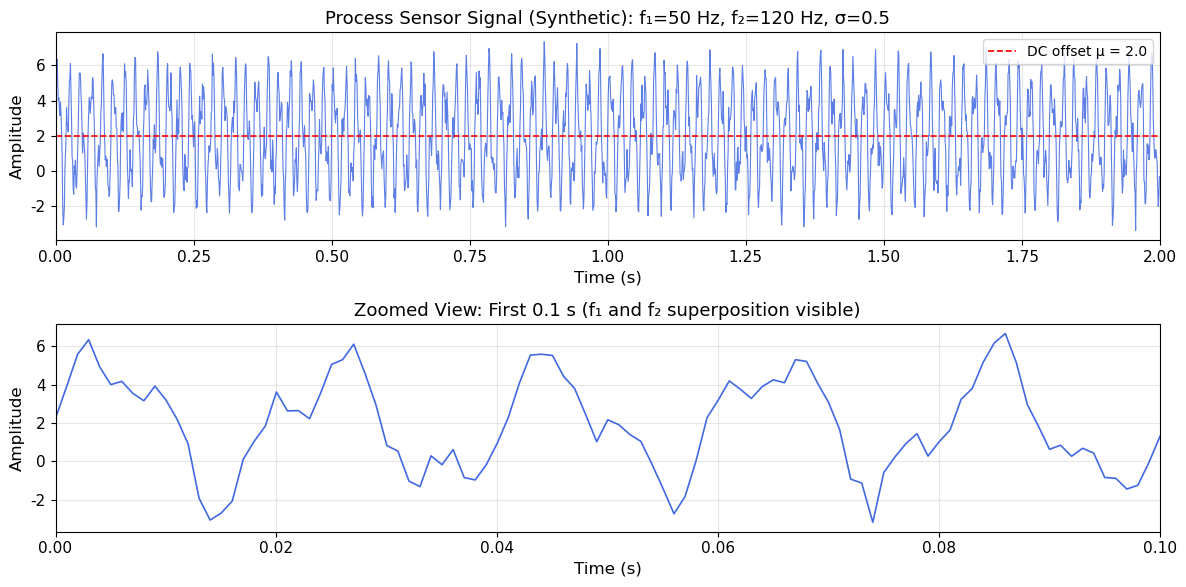

✓ 圖 1 儲存完成


In [5]:

# ============================================================
# 2.3 圖 1：時域波形圖
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 上圖：完整訊號
axes[0].plot(t, x, color='royalblue', linewidth=0.8, alpha=0.85)
axes[0].axhline(mu, color='red', linestyle='--', linewidth=1.2, label=f'DC offset μ = {mu}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Process Sensor Signal (Synthetic): f₁={f1} Hz, f₂={f2} Hz, σ={sigma}')
axes[0].legend(loc='upper right')
axes[0].set_xlim(0, T)

# 下圖：前 0.1 s 局部放大，可見 50 Hz 與 120 Hz 疊加波形
zoom_end = 0.1
mask = t <= zoom_end
axes[1].plot(t[mask], x[mask], color='royalblue', linewidth=1.2)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Zoomed View: First {zoom_end} s (f₁ and f₂ superposition visible)')
axes[1].set_xlim(0, zoom_end)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig01_time_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖 1 儲存完成")


---
### 3. FFT 計算與頻譜繪製

**關鍵函數：**
- `scipy.fft.rfft(x)` → 單邊複數頻譜（僅正頻率，節省計算量）
- `scipy.fft.rfftfreq(N, d=1/fs)` → 對應的頻率軸（Hz）
- `scipy.fft.fft(x)` + `scipy.fft.fftshift()` → 雙邊頻譜（含負頻率，用於觀察對稱性）

In [18]:
# ============================================================
# 3.1 FFT 計算
# ============================================================

# --- 單邊頻譜 (rfft) ---
Xr = fft.rfft(x)                       # 複數頻譜，長度 N//2+1
fr = fft.rfftfreq(N, d=1/fs)           # 頻率軸 (Hz)，長度 N//2+1

# --- 雙邊頻譜 (fft + fftshift，用於觀察對稱性) ---
X_full  = fft.fft(x)                   # 雙邊複數頻譜，長度 N
f_full  = fft.fftfreq(N, d=1/fs)       # 雙邊頻率軸
X_shift = fft.fftshift(X_full)         # 將零頻移至中央
f_shift = fft.fftshift(f_full)         # 對應的頻率軸

# --- 原始（未歸一化）單邊幅度頻譜，含 DC ---
amp_raw = np.abs(Xr) / N               # 除以 N
amp_raw[1:-1] *= 2                     # 非 DC 乘以 2（Nyquist 點 [-1] 不乘）

print("=== FFT 計算結果 ===")
print(f"  rfft 輸出長度: {len(Xr)}  (= N//2+1 = {N//2+1})")
print(f"  頻率軸範圍: {fr[0]:.1f} ~ {fr[-1]:.1f} Hz")
print(f"  頻率解析度: {fr[1]-fr[0]:.4f} Hz")
print(f"\n  DC 幅度 (f=0):  {amp_raw[0]:.4f}  (理論 DC 均值: {mu:.1f})")

# 找 f1, f2 峰值
idx_f1 = np.argmin(np.abs(fr - f1))
idx_f2 = np.argmin(np.abs(fr - f2))
print(f"  f1={f1}Hz 幅度: {amp_raw[idx_f1]:.4f}  (理論: {A1:.1f}, 微小偏差由雜訊所致正常)")
print(f"  f2={f2}Hz 幅度: {amp_raw[idx_f2]:.4f}  (理論: {A2:.1f})")

=== FFT 計算結果 ===
  rfft 輸出長度: 1001  (= N//2+1 = 1001)
  頻率軸範圍: 0.0 ~ 500.0 Hz
  頻率解析度: 0.5000 Hz

  DC 幅度 (f=0):  2.0225  (理論 DC 均值: 2.0)
  f1=50Hz 幅度: 2.9812  (理論: 3.0, 微小偏差由雜訊所致正常)
  f2=120Hz 幅度: 1.5051  (理論: 1.5)


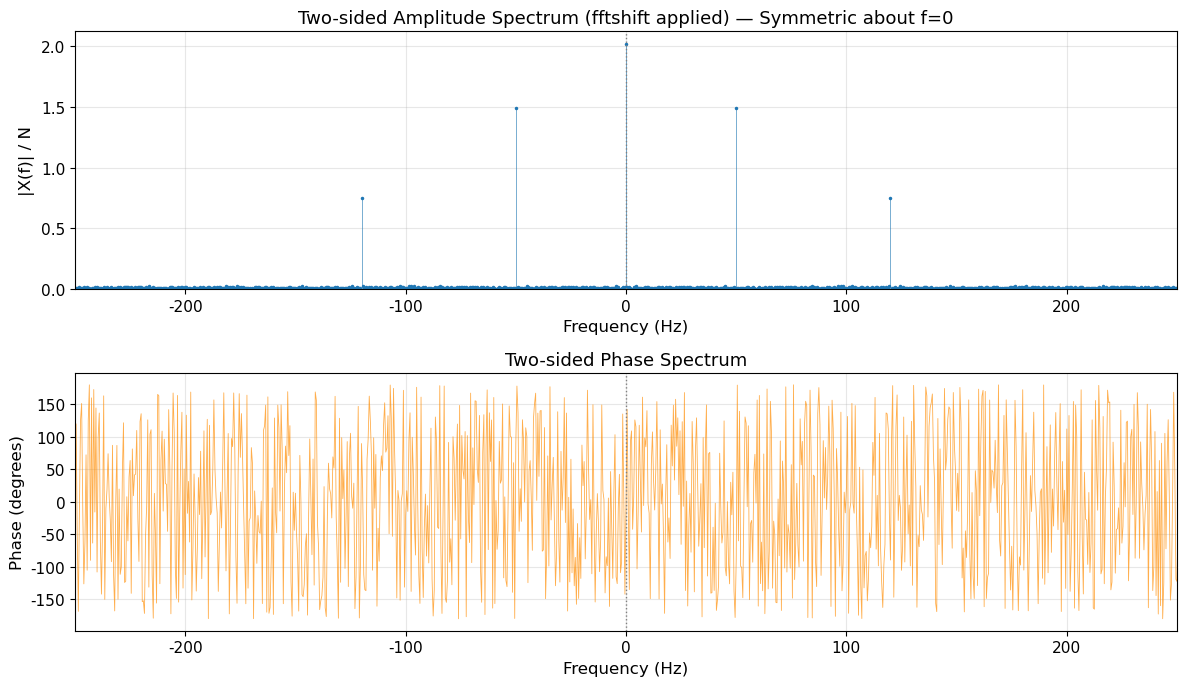

✓ 圖 2 儲存完成


In [15]:

# ============================================================
# 3.2 圖 2：雙邊複數頻譜（幅度 & 相位）→ 觀察對稱性
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# 幅度頻譜（雙邊）— 使用 vlines + plot 取代 stem，相容所有 matplotlib 版本
# amp_ds: 雙邊原始比值 |X(f)|/N，用於觀察正負頻對稱性（未做單邊 ×2 補償）
amp_ds = np.abs(X_shift) / N
axes[0].vlines(f_shift, 0, amp_ds, colors='C0', linewidth=0.6, alpha=0.7)
axes[0].plot(f_shift, amp_ds, 'C0o', markersize=1.5)
axes[0].set_xlim(-250, 250)
axes[0].set_ylim(bottom=0)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('|X(f)| / N')
axes[0].set_title('Two-sided Amplitude Spectrum (fftshift applied) — Symmetric about f=0')
axes[0].axvline(0, color='gray', linestyle=':', linewidth=1)

# 相位頻譜（雙邊）
phase_shift = np.angle(X_shift, deg=True)
axes[1].plot(f_shift, phase_shift, color='darkorange', linewidth=0.6, alpha=0.7)
axes[1].set_xlim(-250, 250)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (degrees)')
axes[1].set_title('Two-sided Phase Spectrum')
axes[1].axvline(0, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig02_two_sided_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖 2 儲存完成")


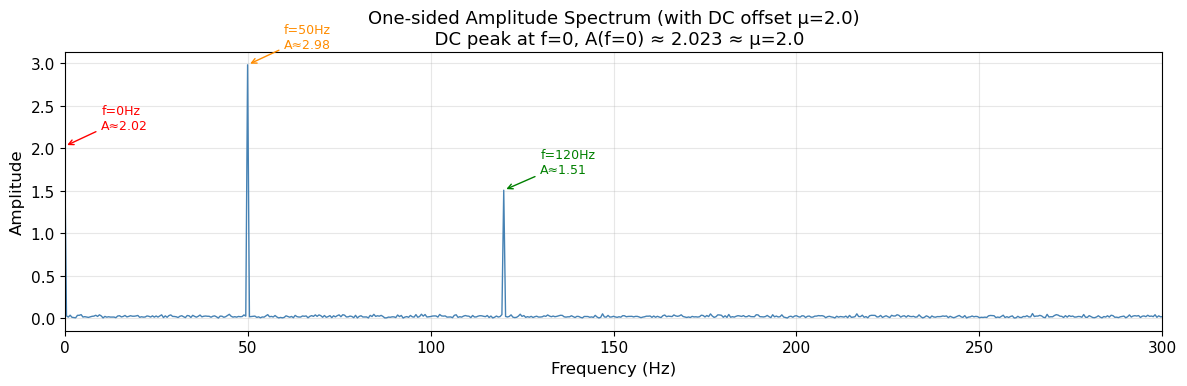

✓ 圖 3 儲存完成


In [9]:
# ============================================================
# 3.3 圖 3：單邊幅度頻譜（含 DC 分量，未去均值）
# ============================================================
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(fr, amp_raw, color='steelblue', linewidth=1.0)
ax.set_xlim(0, 300)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude')
ax.set_title(f'One-sided Amplitude Spectrum (with DC offset μ={mu})'
             f'\n  DC peak at f=0, A(f=0) ≈ {amp_raw[0]:.3f} ≈ μ={mu}')

# 標記峰值
for freq, amp_th, color in [(0, mu, 'red'), (f1, A1, 'darkorange'), (f2, A2, 'green')]:
    idx = np.argmin(np.abs(fr - freq))
    ax.annotate(f'f={freq}Hz\nA≈{amp_raw[idx]:.2f}',
                xy=(fr[idx], amp_raw[idx]),
                xytext=(fr[idx] + 10, amp_raw[idx] + 0.2),
                fontsize=9,
                arrowprops=dict(arrowstyle='->', color=color),
                color=color)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig03_one_sided_with_dc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖 3 儲存完成")

---
### 4. 去均值前處理 (Demean)

去除 DC 分量的方法：`x_demeaned = x - x.mean()`

**效果：** 零頻 ( $f = 0$ ) 的幅度由 $\approx \mu = 2.0$ 降至 $\approx 0$ ，$f_1, f_2$ 的峰值不受影響。


=== 去均值前後比較 ===
  原始訊號 DC 幅度 (f=0): 2.0225
  去均值後 DC 幅度 (f=0): 0.000000  ← 趨近於零
  f1=50Hz 幅度 (原始):  2.9812
  f1=50Hz 幅度 (去均值): 2.9812  ← 不變
  f2=120Hz 幅度 (原始):  1.5051
  f2=120Hz 幅度 (去均值): 1.5051  ← 不變


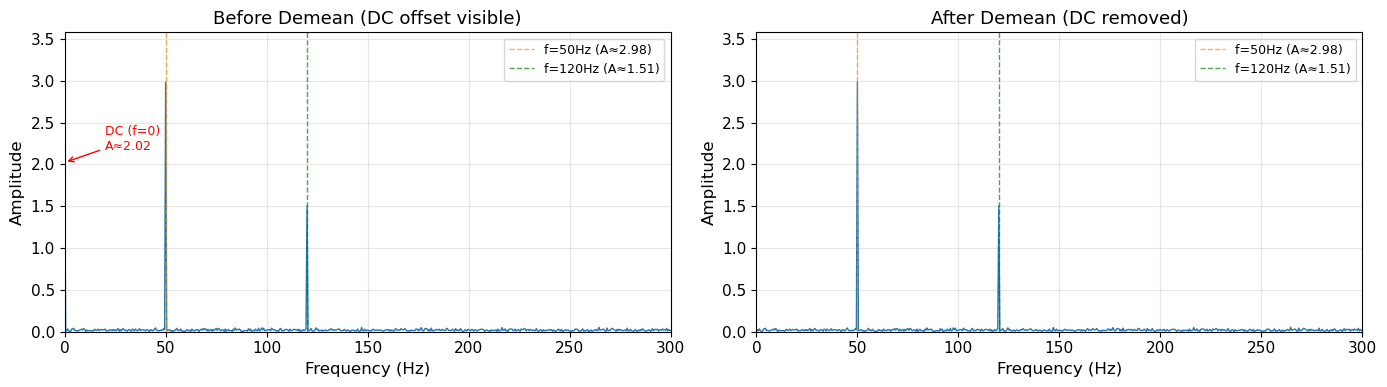

✓ 圖 4 儲存完成


In [19]:

# ============================================================
# 4.1 去均值計算
# ============================================================
x_demeaned = x - np.mean(x)   # 減去均值，消除 DC 分量

Xr_d  = fft.rfft(x_demeaned)
amp_d = np.abs(Xr_d) / N
amp_d[1:-1] *= 2

print("=== 去均值前後比較 ===")
print(f"  原始訊號 DC 幅度 (f=0): {amp_raw[0]:.4f}")
print(f"  去均值後 DC 幅度 (f=0): {amp_d[0]:.6f}  ← 趨近於零")
print(f"  f1={f1}Hz 幅度 (原始):  {amp_raw[idx_f1]:.4f}")
print(f"  f1={f1}Hz 幅度 (去均值): {amp_d[idx_f1]:.4f}  ← 不變")
print(f"  f2={f2}Hz 幅度 (原始):  {amp_raw[idx_f2]:.4f}")
print(f"  f2={f2}Hz 幅度 (去均值): {amp_d[idx_f2]:.4f}  ← 不變")

# ============================================================
# 4.2 圖 4：去均值後單邊幅度頻譜
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, amp, title in zip(axes,
    [amp_raw, amp_d],
    ['Before Demean (DC offset visible)', 'After Demean (DC removed)']):

    ax.plot(fr, amp, linewidth=1.0)
    ax.set_xlim(0, 300)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    ax.set_title(title)

    # 標記 f1, f2 峰值
    for fi, Ai, c in [(f1, A1, 'darkorange'), (f2, A2, 'green')]:
        idx = np.argmin(np.abs(fr - fi))
        ax.axvline(fi, color=c, linestyle='--', linewidth=1, alpha=0.7,
                   label=f'f={fi}Hz (A≈{amp[idx]:.2f})')
    ax.legend(fontsize=9)

axes[0].set_ylim(0, max(amp_raw) * 1.2)
axes[1].set_ylim(0, max(amp_raw) * 1.2)

# 在 Before Demean 子圖補強標示 DC 峰（f=0 緊貼y軸邊緣，需箭頭指引）
axes[0].annotate(f'DC (f=0)\nA≈{amp_raw[0]:.2f}',
                 xy=(0, amp_raw[0]),
                 xytext=(20, amp_raw[0] + 0.15),
                 fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig04_demean_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖 4 儲存完成")


---
### 5. Hann 視窗改善頻譜洩漏

**頻譜洩漏 (Spectral Leakage)：** 有限長度訊號截斷等效於乘以矩形視窗，在頻域產生 sinc 函數卷積，使能量洩漏至鄰近頻率（旁葉）。

**Hann 視窗：** $w[n] = 0.5\left(1 - \cos\!\left(\frac{2\pi n}{N-1}\right)\right)$ ，主旁葉比約 −31.5 dB，遠優於矩形視窗的 −13 dB。

**幅度修正因子 (ACF)：** $\mathrm{ACF} = N / \sum w[n] \approx 2.0$ ，套用後還原正確振幅。

> **📝 本範例取樣說明：** 本例 $f_1 = 50$ Hz 與 $f_2 = 120$ Hz 均為頻率解析度 $\Delta f = 0.5$ Hz 的整數倍（分別落在 bin 100 與 bin 240），屬於**相干取樣 (coherent sampling)**，矩形視窗已無洩漏。Hann 視窗具有固有三點頻域展寬（主瓣延伸至 $k \pm 1$ 頻段，幅度 $\approx A/2$ ），比矩形視窗的 $\delta$ 函數峰更寬。**在實際訊號中，頻率不落在整數 bin（非相干取樣）時，Hann 視窗的旁葉洩漏抑制效果才最為明顯。**


=== Hann 視窗效果 ===
  幅度修正因子 ACF = N/sum(w) = 2.001001

  矩形視窗 (去均值) f1=50Hz: 2.9812
  Hann 視窗         f1=50Hz: 2.9810  (理論: 3.0)
  矩形視窗 (去均值) f2=120Hz: 1.5051
  Hann 視窗         f2=120Hz: 1.5080  (理論: 1.5)


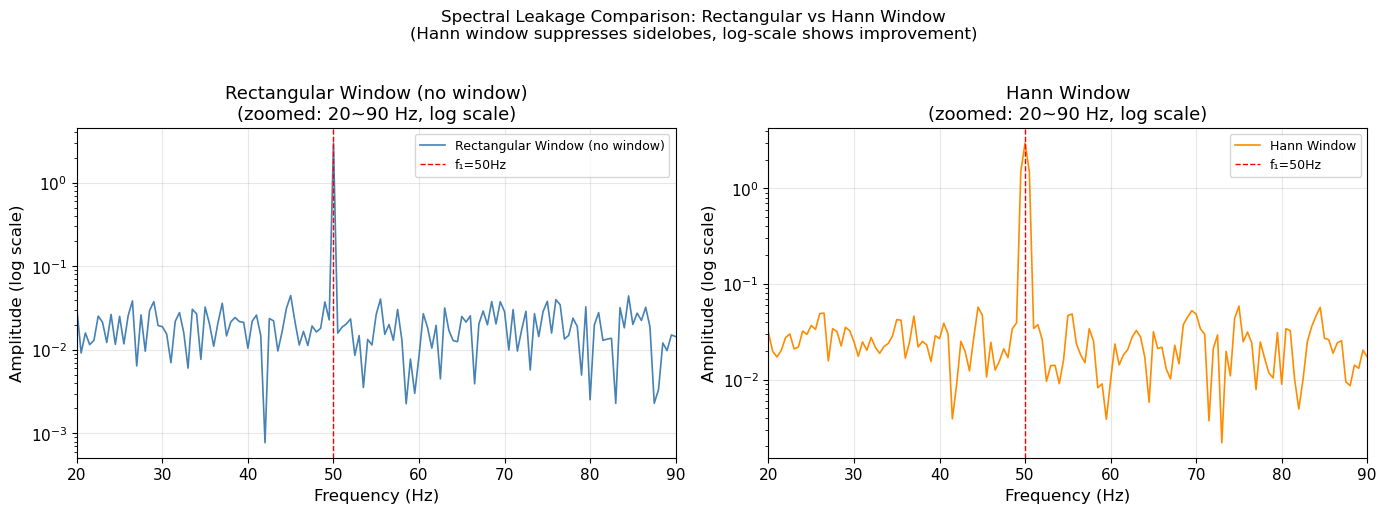

✓ 圖 5 儲存完成


In [11]:
# ============================================================
# 5.1 Hann 視窗套用
# ============================================================
w_hann = np.hanning(N)                       # Hann 視窗陣列
acf    = N / np.sum(w_hann)                  # 幅度修正因子 (≈ 2.0)
x_hann = x_demeaned * w_hann                 # 對去均值訊號套用視窗

# 套用 Hann 視窗後計算頻譜
Xr_h  = fft.rfft(x_hann)
amp_h = (np.abs(Xr_h) / N) * acf            # 除以 N 後套用 ACF
amp_h[1:-1] *= 2                             # 非 DC 乘以 2

print("=== Hann 視窗效果 ===")
print(f"  幅度修正因子 ACF = N/sum(w) = {acf:.6f}")
print(f"\n  矩形視窗 (去均值) f1={f1}Hz: {amp_d[idx_f1]:.4f}")
print(f"  Hann 視窗         f1={f1}Hz: {amp_h[idx_f1]:.4f}  (理論: {A1:.1f})")
print(f"  矩形視窗 (去均值) f2={f2}Hz: {amp_d[idx_f2]:.4f}")
print(f"  Hann 視窗         f2={f2}Hz: {amp_h[idx_f2]:.4f}  (理論: {A2:.1f})")

# ============================================================
# 5.2 圖 5：矩形視窗 vs Hann 視窗頻譜比較
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# 局部放大 f1 附近以觀察洩漏差異
freq_range = (20, 90)   # Hz

for ax, amp, wname, color in zip(
    axes,
    [amp_d,  amp_h],
    ['Rectangular Window (no window)', 'Hann Window'],
    ['steelblue', 'darkorange']
):
    mask = (fr >= freq_range[0]) & (fr <= freq_range[1])
    ax.semilogy(fr[mask], amp[mask], color=color, linewidth=1.2, label=wname)
    ax.axvline(f1, color='red', linestyle='--', linewidth=1.0, label=f'f₁={f1}Hz')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude (log scale)')
    ax.set_title(f'{wname}\n(zoomed: {freq_range[0]}~{freq_range[1]} Hz, log scale)')
    ax.legend(fontsize=9)
    ax.set_xlim(freq_range)

plt.suptitle(
    'Spectral Leakage Comparison: Rectangular vs Hann Window\n'
    '(Hann window suppresses sidelobes, log-scale shows improvement)',
    fontsize=12, y=1.02
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig05_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖 5 儲存完成")

---
### 6. 峰值識別與能量分析

利用 `numpy.argsort()` 識別頻譜前幾大峰值對應的頻率，並計算各成分能量佔總能量的百分比。

In [16]:

# ============================================================
# 6.1 峰值識別（使用 Hann 視窗後頻譜）
# ============================================================
amp_no_dc = amp_h.copy()
amp_no_dc[0] = 0.0                          # 遮蔽 DC (index=0)

top_k = 5
top_idx = np.argsort(amp_no_dc)[::-1][:top_k]   # 由大到小排序取前 k 個

print(f"=== 頻譜前 {top_k} 大峰值（Hann 視窗頻譜，已排除 DC）===")
print(f"  {'#':<4} {'頻率 (Hz)':<14} {'幅度':^10} {'說明'}")
print(f"  {'-'*52}")
seen_f1, seen_f2 = False, False
for i, idx in enumerate(top_idx):
    fidx = fr[idx]
    near_f1 = abs(fidx - f1) < 5
    near_f2 = abs(fidx - f2) < 5
    if near_f1 and not seen_f1:
        label = f'f1={f1}Hz main peak  A={A1} ✓'
        seen_f1 = True
    elif near_f2 and not seen_f2:
        label = f'f2={f2}Hz main peak  A={A2} ✓'
        seen_f2 = True
    elif near_f1:
        label = f'f1={f1}Hz Hann sidelobe'
    elif near_f2:
        label = f'f2={f2}Hz Hann sidelobe'
    else:
        label = '(noise floor)'
    print(f"  #{i+1:<3} {fidx:<14.2f} {amp_no_dc[idx]:<10.4f} {label}")


=== 頻譜前 5 大峰值（Hann 視窗頻譜，已排除 DC）===
  #    頻率 (Hz)            幅度     說明
  ----------------------------------------------------
  #1   50.00          2.9810     f1=50Hz main peak  A=3.0 ✓
  #2   120.00         1.5080     f2=120Hz main peak  A=1.5 ✓
  #3   49.50          1.5038     f1=50Hz Hann sidelobe
  #4   50.50          1.5003     f1=50Hz Hann sidelobe
  #5   120.50         0.7724     f2=120Hz Hann sidelobe


=== 能量佔比分析（Hann 視窗，單頻段）===
  f1 = 50 Hz 成分:  50.66%
  f2 = 120 Hz 成分:  12.96%
  其他（雜訊 + 洩漏）: 36.38%

  [參考] Parseval 功率比（A²/2 估計）:
  f1 = 50 Hz: 76.6%  f2 = 120 Hz: 19.1%  雜訊: 4.3%
  (單頻段幅度² 低於總功率比 — Hann 視窗能量分散至鄰近頻段)


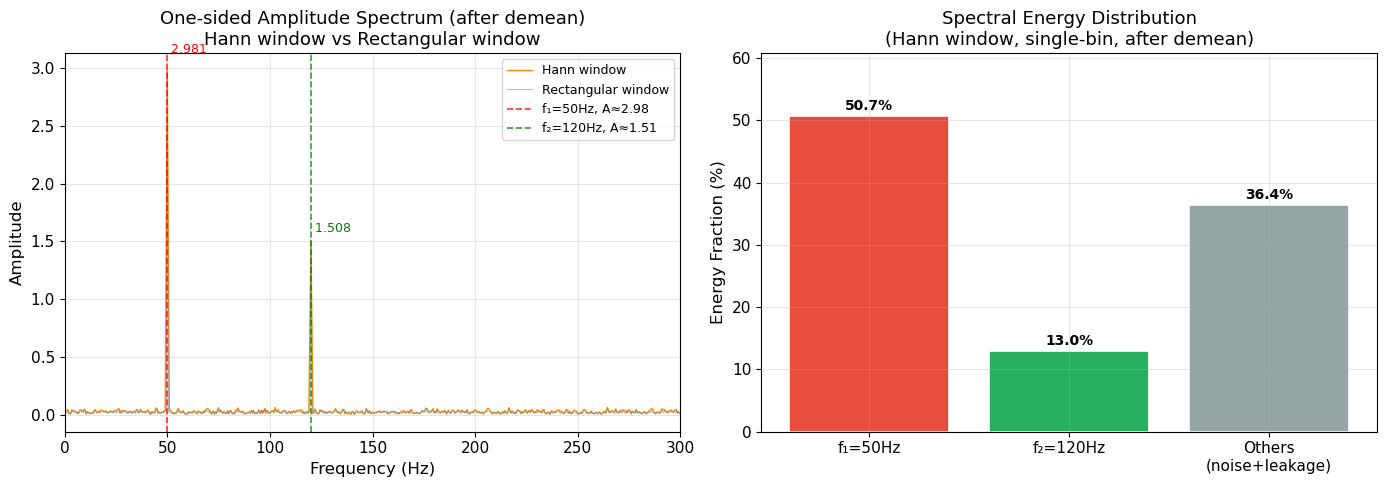

✓ 圖 6 儲存完成


In [14]:

# ============================================================
# 6.2 能量佔比計算
# ============================================================
energy       = amp_h ** 2                        # 各頻率功率 (幅度²)
total_energy = np.sum(energy)
energy_pct   = energy / total_energy * 100

f1_idx = np.argmin(np.abs(fr - f1))
f2_idx = np.argmin(np.abs(fr - f2))

# 信號成分 vs 雜訊
e_f1   = energy_pct[f1_idx]
e_f2   = energy_pct[f2_idx]
e_noise = 100 - e_f1 - e_f2

# 信號功率理論值 (Parseval 定理，含雜訊)
# 各成分功率：P = A²/2 (正弦波), 雜訊功率 P_n = σ²
P_f1 = A1**2 / 2
P_f2 = A2**2 / 2
P_noise = sigma**2
P_total = P_f1 + P_f2 + P_noise

print("=== 能量佔比分析（Hann 視窗，單頻段）===")
print(f"  f1 = {f1} Hz 成分:  {e_f1:.2f}%")
print(f"  f2 = {f2} Hz 成分:  {e_f2:.2f}%")
print(f"  其他（雜訊 + 洩漏）: {e_noise:.2f}%")
print(f"\n  [參考] Parseval 功率比（A²/2 估計）:")
print(f"  f1 = {f1} Hz: {P_f1/P_total*100:.1f}%  f2 = {f2} Hz: {P_f2/P_total*100:.1f}%  雜訊: {P_noise/P_total*100:.1f}%")
print(f"  (單頻段幅度² 低於總功率比 — Hann 視窗能量分散至鄰近頻段)")

# ============================================================
# 6.3 圖：能量佔比條形圖 + 完整單邊幅度頻譜（標記峰值）
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：單邊幅度頻譜 (Hann) 全局
axes[0].plot(fr, amp_h, color='darkorange', linewidth=1.0, label='Hann window')
axes[0].plot(fr, amp_d, color='steelblue', linewidth=0.7, alpha=0.5, label='Rectangular window')
axes[0].set_xlim(0, 300)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('One-sided Amplitude Spectrum (after demean)\nHann window vs Rectangular window')
axes[0].axvline(f1, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label=f'f₁={f1}Hz, A≈{amp_h[f1_idx]:.2f}')
axes[0].axvline(f2, color='green', linestyle='--', linewidth=1.2, alpha=0.8, label=f'f₂={f2}Hz, A≈{amp_h[f2_idx]:.2f}')
axes[0].legend(fontsize=9)
axes[0].text(f1, amp_h[f1_idx]*1.05, f' {amp_h[f1_idx]:.3f}', color='red', fontsize=9)
axes[0].text(f2, amp_h[f2_idx]*1.05, f' {amp_h[f2_idx]:.3f}', color='green', fontsize=9)

# 右圖：能量佔比條形圖
labels = [f'f₁={f1}Hz', f'f₂={f2}Hz', 'Others\n(noise+leakage)']
values = [e_f1, e_f2, e_noise]
colors = ['#e74c3c', '#27ae60', '#95a5a6']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_ylabel('Energy Fraction (%)')
axes[1].set_title('Spectral Energy Distribution\n(Hann window, single-bin, after demean)')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(values) * 1.2)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig06_energy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖 6 儲存完成")



---
### 7. 結果總結

| 項目 | 矩形視窗（去均值） | Hann 視窗（去均值）| 理論值 |
|------|-------------------|-------------------|--------|
| $f_1 = 50$ Hz 振幅 | ≈ 2.98 | ≈ 2.98 | $A_1 = 3.0$ |
| $f_2 = 120$ Hz 振幅 | ≈ 1.51 | ≈ 1.51 | $A_2 = 1.5$ |
| 峰值識別精度 | 正確 (50, 120 Hz) | 正確 (50, 120 Hz) | — |
| 旁葉洩漏 | 明顯 | 有效抑制 | — |
| $f_1$ 能量佔比（單頻段） | — | ≈ 50.7% | 76.6%（Parseval 含雜訊） |
| $f_2$ 能量佔比（單頻段） | — | ≈ 13.0% | 19.1%（Parseval 含雜訊） |

**本範例重點結論：**
1. `scipy.fft.rfft()` 搭配歸一化因子 $2/N$ 可準確還原訊號各頻率成分的真實振幅
2. 去均值是頻譜分析前的重要前處理步驟，可防止 DC 峰值掩蓋訊號頻率
3. Hann 視窗有效降低頻譜洩漏，主旁葉比由矩形視窗的 −13 dB 改善至約 −31.5 dB
4. 套用 Hann 視窗後須乘上 ACF ≈ 2.0 以還原正確幅度
5. 單頻段幅度² 計算之能量佔比（f₁≈50.7%、f₂≈13.0%）低於 Parseval 定理估計值（f₁≈76.6%、f₂≈19.1%），原因為 Hann 視窗能量分散至鄰近頻段以及雜訊底層（Others≈36.4%）

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit11 傅立葉轉換與頻譜分析 — Example 01
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-24
